## Simple Grover Circuit


In [1]:
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
import numpy as np

### Step 1: Building the diffuser

In [27]:
def diffuser (n=4,name='V'):
    qc=QuantumCircuit(n, name=name)

    st=""
    for i in range (n-1):
        st+="0"
    
    qc.h(range(n))
    qc.x(n-1)
    qc.h(n-1)
    qc.mcx(list(i for i in range(n-1)),n-1,ctrl_state=st)
    qc.h(range(n))
    qc.x(n-1)
    qc.h(n-1)

    return qc

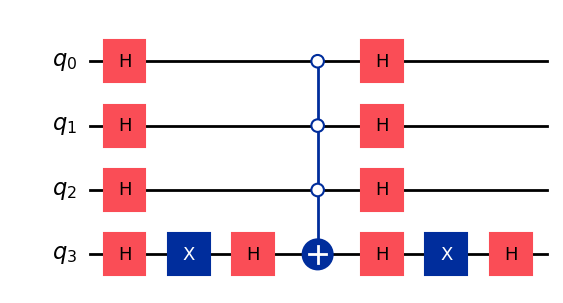

In [28]:
check=diffuser()
check.draw('mpl')

### Step 2: Building the phase oracle

In [66]:
def phase_oracle(n=4,name="Uf"):
    qc=QuantumCircuit(n,name=name)

    st=''
    for i in range ((n-1)//2):
        st+="01"
    if (n-1)%2:
        st="1"+st
        
    qc.x(n-1)
    qc.h(n-1)
    qc.mcx(list(i for i in range(n-1)),n-1,ctrl_state=st)
    qc.h(n-1)
    qc.x(n-1)
    
    return qc

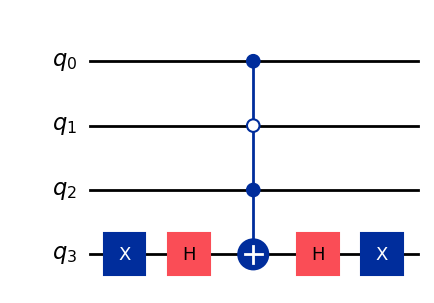

In [67]:
p= phase_oracle()
p.draw('mpl')

### Step 3: Assembling Grovers Circuit

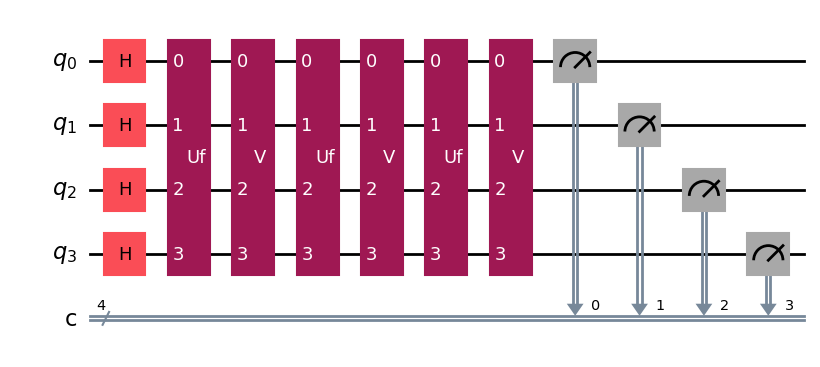

In [117]:
n=4
grover_circuit= QuantumCircuit(n,n)
nsol=1 #number of solutions
alpha=np.arcsin(np.sqrt(nsol/2**(n))) # Determine alpha
r = round(np.pi/(4*alpha)-0.5) # Determine r

grover_circuit.h(range(n))

for j in range(r):
    grover_circuit.append(phase_oracle(n=n),range(n))
    grover_circuit.append(diffuser(n=n),range(n))

grover_circuit.measure(range(n), range(n))

grover_circuit.draw('mpl')


### Step 3: Running on Simulator vs. Real Hardware

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=4>)), metadata={'shots': 1000, 'circuit_metadata': {}})], metadata={'version': 2})


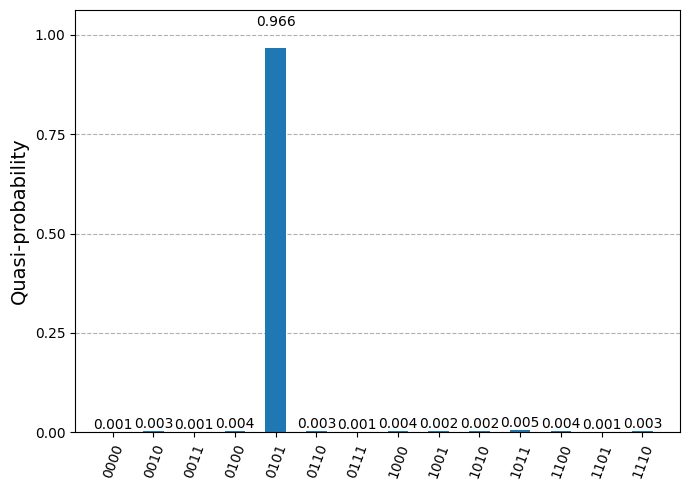

In [118]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit import transpile
simulator_aer=AerSimulator()
gr_trsp = transpile(grover_circuit, simulator_aer)
sampler_aer = Sampler(simulator_aer)
job = sampler_aer.run([(gr_trsp, None,1000)])
result =  job.result()
print(result)
counts = result[0].data.c.get_counts()
from qiskit.visualization import plot_histogram, plot_distribution

plot_distribution(counts)

In [113]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager

service=QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)


gr_transpiled = pm.run(grover_circuit)

##gr_transpiled.draw("mpl")


qiskit_runtime_service.__init__:WARNING:2025-11-18 00:13:08,986: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-18 00:13:09,189: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2025-11-18 00:13:10,652: Using instance: open-instance, plan: open


In [114]:
sampler = Sampler(backend)

job = sampler.run([(gr_transpiled, None,5000)])
job_id = job.job_id()
print(job_id)


d4dqojcl291s73e7rj20


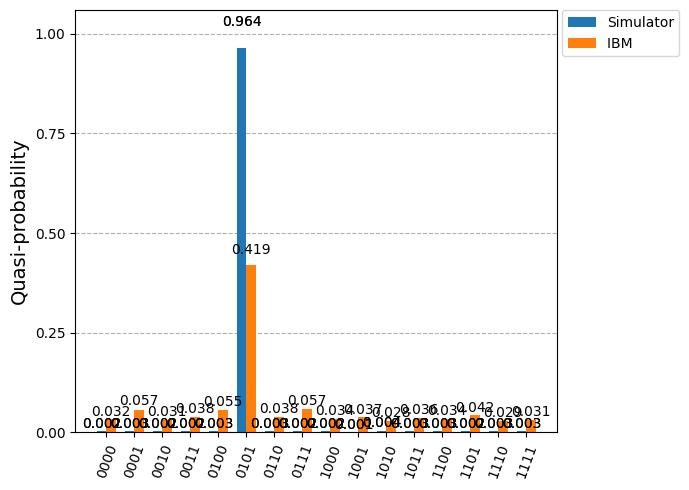

In [116]:
job = service.job('d4dqojcl291s73e7rj20')
result = job.result()
counts_ibm = result[0].data.c.get_counts()
from qiskit.visualization import plot_histogram, plot_distribution

plot_distribution([counts,counts_ibm], legend = ['Simulator', 'IBM '])